In [1]:
import os
import sqlite3
import pandas as pd
import time
import backoff
from typing import Annotated, Dict, List, Optional, TypedDict, Literal
from typing_extensions import TypedDict
from dotenv import load_dotenv

import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool

# Updated LangGraph imports - no ToolExecutor needed
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode  # Use ToolNode instead of ToolExecutor

# Configure Gemini API
load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
os.environ["GOOGLE_API_KEY"] = GEMINI_API_KEY

# Rate limiting configuration
MAX_RETRIES = 5
BASE_DELAY = 1
MAX_DELAY = 60

/Users/gokul/miniconda3/envs/mtp/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class RCAState(TypedDict):
    """State schema for Root Cause Analysis agent"""
    messages: Annotated[List, add_messages]
    user_query: str
    current_pattern: Optional[str]
    checklist_items: List[str]
    executed_queries: List[Dict]
    findings: List[str]
    root_cause_found: bool
    iteration_count: int
    max_iterations: int
    available_metrics: List[str]
    available_tables: List[str]

class GeminiRateLimiter:
    def __init__(self, requests_per_minute=50):
        self.requests_per_minute = requests_per_minute
        self.request_times = []
    
    def wait_if_needed(self):
        """Implement rate limiting logic"""
        now = time.time()
        # Remove requests older than 1 minute
        self.request_times = [t for t in self.request_times if now - t < 60]
        
        if len(self.request_times) >= self.requests_per_minute:
            sleep_time = 60 - (now - self.request_times[0])
            if sleep_time > 0:
                print(f"Rate limit reached. Waiting {sleep_time:.2f} seconds...")
                time.sleep(sleep_time)
        
        self.request_times.append(now)

# Initialize rate limiter and model
rate_limiter = GeminiRateLimiter(requests_per_minute=50)

@backoff.on_exception(
    backoff.expo,
    Exception,
    max_tries=MAX_RETRIES,
    max_time=300
)
def call_gemini_with_backoff(llm, messages):
    """Call Gemini API with exponential backoff"""
    rate_limiter.wait_if_needed()
    return llm.invoke(messages)

# Initialize Gemini model
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash-lite",
    temperature=0.1,
    google_api_key=GEMINI_API_KEY
)


In [3]:
@tool
def query_metrics_csv(csv_filename: str, query_description: str = "basic info") -> str:
    """
    Query metrics CSV files using pandas operations.
    
    Args:
        csv_filename: Name of the CSV file in metrics folder
        query_description: Description of what to query
    
    Returns:
        Query results as string
    """
    try:
        # Load the CSV file
        file_path = f"metrics/{csv_filename}"
        df = pd.read_csv(file_path)
        
        # Return basic info about the dataset
        info = f"Dataset shape: {df.shape}\n"
        info += f"Columns: {list(df.columns)}\n"
        info += f"First few rows:\n{df.head().to_string()}\n"
        info += f"Data types:\n{df.dtypes.to_string()}\n"
        info += f"Basic statistics:\n{df.describe().to_string()}"
        
        return info
    except Exception as e:
        return f"Error querying {csv_filename}: {str(e)}"

@tool
def execute_pandas_code(code: str, csv_filename: str = None) -> str:
    """
    Execute pandas code on metrics data.
    
    Args:
        code: Python pandas code to execute
        csv_filename: Optional CSV filename to load
    
    Returns:
        Execution results
    """
    try:
        # Set up execution environment
        exec_globals = {
            'pd': pd,
            'np': __import__('numpy'),
            'plt': __import__('matplotlib.pyplot')
        }
        exec_locals = {}
        
        # Load CSV if specified
        if csv_filename:
            file_path = f"metrics/{csv_filename}"
            exec_globals['df'] = pd.read_csv(file_path)
        
        # Execute the code
        exec(code, exec_globals, exec_locals)
        
        # Try to capture result
        if 'result' in exec_locals:
            return str(exec_locals['result'])
        elif 'df' in exec_globals and hasattr(exec_globals['df'], 'to_string'):
            return exec_globals['df'].head(10).to_string()
        else:
            return "Code executed successfully - no explicit result returned"
            
    except Exception as e:
        return f"Error executing pandas code: {str(e)}"

@tool
def query_synthetic_database(sql_query: str) -> str:
    """
    Execute SQL query on synthetic database.
    
    Args:
        sql_query: SQL query to execute
    
    Returns:
        Query results
    """
    try:
        conn = sqlite3.connect('synthetic_data/synthetic_data.db')
        df_result = pd.read_sql_query(sql_query, conn)
        conn.close()
        return df_result.to_string()
    except Exception as e:
        return f"Error executing SQL query: {str(e)}"

@tool
def get_database_schema() -> str:
    """Get schema information from synthetic database."""
    try:
        conn = sqlite3.connect('synthetic_data/synthetic_data.db')
        cursor = conn.cursor()
        
        # Get all table names
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()
        
        schema_info = "Database Schema:\n"
        for table in tables:
            table_name = table[0]
            cursor.execute(f"PRAGMA table_info({table_name});")
            columns = cursor.fetchall()
            
            schema_info += f"\nTable: {table_name}\n"
            schema_info += "Columns:\n"
            for col in columns:
                schema_info += f"  - {col[1]} ({col[2]})\n"
        
        conn.close()
        return schema_info
    except Exception as e:
        return f"Error getting database schema: {str(e)}"

@tool
def validate_database_schema() -> str:
    """Get actual database schema and sample data"""
    try:
        conn = sqlite3.connect('synthetic_data/synthetic_data.db')
        
        # Get all tables
        tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
        tables_df = pd.read_sql_query(tables_query, conn)
        
        schema_info = "=== ACTUAL DATABASE SCHEMA ===\n"
        
        for table_name in tables_df['name'].values:
            # Get column info
            columns_query = f"PRAGMA table_info({table_name});"
            columns_df = pd.read_sql_query(columns_query, conn)
            
            # Get sample data
            sample_query = f"SELECT * FROM {table_name} LIMIT 3;"
            sample_df = pd.read_sql_query(sample_query, conn)
            
            schema_info += f"\n--- TABLE: {table_name} ---\n"
            schema_info += f"Columns: {list(columns_df['name'].values)}\n"
            schema_info += f"Sample Data:\n{sample_df.to_string()}\n"
        
        conn.close()
        return schema_info
        
    except Exception as e:
        return f"Schema validation error: {str(e)}"

@tool 
def get_safe_single_table_query(table_name: str, analysis_type: str = "basic") -> str:
    """Generate safe single-table queries for independent tables"""
    
    safe_queries = {
        "inventory": {
            "basic": "SELECT COUNT(*) as total_records, MIN(week) as earliest_week, MAX(week) as latest_week FROM inventory",
            "trends": "SELECT week, AVG(inventory_level) as avg_inventory, COUNT(*) as products FROM inventory GROUP BY week ORDER BY week DESC LIMIT 15",
            "stockouts": "SELECT week, SUM(CASE WHEN stockout_flag = 1 THEN 1 ELSE 0 END) as stockouts FROM inventory GROUP BY week ORDER BY week DESC LIMIT 10"
        },
        "marketing": {
            "basic": "SELECT COUNT(*) as total_campaigns, MIN(week) as earliest_week, MAX(week) as latest_week FROM marketing",
            "spending": "SELECT week, SUM(ad_spend) as total_spend, AVG(discount_percentage) as avg_discount FROM marketing GROUP BY week ORDER BY week DESC LIMIT 15",
            "campaigns": "SELECT week, COUNT(*) as active_campaigns FROM marketing WHERE marketing_campaign_active = 1 GROUP BY week ORDER BY week DESC LIMIT 10"
        },
        "competitor": {
            "basic": "SELECT COUNT(*) as total_records, MIN(week) as earliest_week, MAX(week) as latest_week FROM competitor", 
            "discounts": "SELECT week, COUNT(*) as discount_periods, AVG(competitor_discount_percentage) as avg_discount FROM competitor WHERE competitor_discount_active = 1 GROUP BY week ORDER BY week DESC LIMIT 10",
            "launches": "SELECT week, SUM(competitor_new_product_launch) as new_launches FROM competitor GROUP BY week ORDER BY week DESC LIMIT 10"
        },
        "customer_behavior": {
            "basic": "SELECT COUNT(*) as total_records, AVG(return_rate) as avg_return_rate, AVG(churn_rate) as avg_churn FROM customer_behavior",
            "trends": "SELECT week, AVG(return_rate) as avg_returns, AVG(churn_rate) as avg_churn, AVG(complaints_count) as avg_complaints FROM customer_behavior GROUP BY week ORDER BY week DESC LIMIT 15",
            "segments": "SELECT customer_segment, COUNT(*) as records, AVG(return_rate) as avg_return_rate FROM customer_behavior GROUP BY customer_segment"
        },
        "logistics": {
            "basic": "SELECT COUNT(*) as total_records, AVG(avg_shipping_delay_days) as avg_delay, AVG(delivery_success_rate) as avg_success FROM logistics",
            "delays": "SELECT week, AVG(avg_shipping_delay_days) as avg_delay, COUNT(*) as regions FROM logistics GROUP BY week ORDER BY week DESC LIMIT 15",
            "regions": "SELECT region, AVG(avg_shipping_delay_days) as avg_delay, AVG(delivery_success_rate) as success_rate FROM logistics GROUP BY region"
        },
        "external_factors": {
            "basic": "SELECT COUNT(*) as total_records, MIN(week) as earliest_week, MAX(week) as latest_week FROM external_factors",
            "economy": "SELECT week, AVG(economic_index) as avg_econ_index, AVG(temperature) as avg_temp FROM external_factors GROUP BY week ORDER BY week DESC LIMIT 15",
            "holidays": "SELECT week, holiday_flag, COUNT(*) as occurrences FROM external_factors GROUP BY week, holiday_flag ORDER BY week DESC LIMIT 20"
        },
        "pricing": {
            "basic": "SELECT COUNT(*) as total_records, AVG(base_price) as avg_base_price FROM pricing",
            "changes": "SELECT week, COUNT(*) as price_changes, AVG(price_change_percentage) as avg_change FROM pricing WHERE price_change_flag = 1 GROUP BY week ORDER BY week DESC LIMIT 10",
            "products": "SELECT product_id, AVG(base_price) as avg_price, COUNT(*) as records FROM pricing GROUP BY product_id ORDER BY avg_price DESC LIMIT 15"
        }
    }
    
    return safe_queries.get(table_name, {}).get(analysis_type, f"SELECT COUNT(*) FROM {table_name}")


# Add this to your tools list
tools = [query_metrics_csv, execute_pandas_code, query_synthetic_database, 
         get_database_schema, validate_database_schema, get_safe_single_table_query]



In [4]:
def test_independent_tables():
    """Test queries on independent tables"""
    print("🧪 Testing Independent Table Queries...")
    
    tables = ['inventory', 'marketing', 'competitor', 'customer_behavior', 'logistics']
    
    for table in tables:
        try:
            # Test basic query
            query = get_safe_single_table_query.invoke({"table_name": table, "analysis_type": "basic"})
            result = query_synthetic_database.invoke({"sql_query": query})
            print(f"✅ {table} basic query: {str(result)[:100]}...")
            
            # Test trends query  
            trends_query = get_safe_single_table_query.invoke({"table_name": table, "analysis_type": "trends"})
            trends_result = query_synthetic_database.invoke({"sql_query": trends_query})
            print(f"✅ {table} trends query: {str(trends_result)[:100]}...")
            
        except Exception as e:
            print(f"❌ {table} test failed: {e}")
    
    print("🎯 Independent table testing completed!")

# Test the fixes
test_independent_tables()


🧪 Testing Independent Table Queries...
✅ inventory basic query:    total_records earliest_week latest_week
0        1276208    1900-01-01  2014-12-08...
✅ inventory trends query:           week  avg_inventory  products
0   2014-12-08     740.143024     10292
1   2014-12-01     7...
✅ marketing basic query:    total_campaigns earliest_week latest_week
0          1276208    1900-01-01  2014-12-08...
✅ marketing trends query:    COUNT(*)
0   1276208...
✅ competitor basic query:    total_records earliest_week latest_week
0           1612    1900-01-01  2014-12-08...
✅ competitor trends query:    COUNT(*)
0      1612...
✅ customer_behavior basic query:    total_records  avg_return_rate  avg_churn
0            372         0.107277   0.080933...
✅ customer_behavior trends query:           week  avg_returns  avg_churn  avg_complaints
0   2014-12-08     0.088234   0.061335       ...
✅ logistics basic query:    total_records  avg_delay  avg_success
0           1612   1.933002     0.897895...
✅ l

In [5]:
def pattern_analysis_node(state: RCAState):
    """Analyze user query and identify patterns to investigate"""
    print("🔍 Starting pattern analysis...")
    
    messages = [
        SystemMessage(content="""You are a root cause analysis expert. 
        Analyze the user's query about revenue patterns or other metrics.
        Identify the specific pattern that needs investigation and provide
        a clear description of what needs to be analyzed."""),
        HumanMessage(content=f"User query: {state['user_query']}")
    ]
    
    try:
        response = call_gemini_with_backoff(llm, messages)
        pattern = response.content
        
        return {
            "current_pattern": pattern,
            "messages": [AIMessage(content=f"Pattern identified: {pattern}")]
        }
    except Exception as e:
        return {
            "current_pattern": f"Error in pattern analysis: {str(e)}",
            "messages": [AIMessage(content=f"Error in pattern analysis: {str(e)}")]
        }

def checklist_generation_node(state: RCAState):
    """Generate investigation checklist based on available data"""
    print("📋 Generating investigation checklist...")
    
    # Get schema information
    try:
        schema_info = get_database_schema.invoke({})
    except:
        schema_info = "Schema unavailable"
    
    messages = [
        SystemMessage(content=f"""Based on the identified pattern and available data sources,
        generate exactly 20 specific investigation items to check for root causes.
        
        Available data sources:
        {schema_info}
        
        Current pattern: {state['current_pattern']}
        
        Each checklist item should be actionable and specific, focusing on:
        1. Data correlations
        2. Time-based patterns  
        3. Categorical breakdowns
        4. Statistical anomalies
        5. Business logic validation
        
        Format as a numbered list."""),
        HumanMessage(content="Generate the investigation checklist.")
    ]
    
    try:
        response = call_gemini_with_backoff(llm, messages)
        checklist_content = response.content
        
        # Extract checklist items
        checklist_items = []
        for line in checklist_content.split('\n'):
            if line.strip() and (line.strip()[0].isdigit() or line.strip().startswith('-')):
                checklist_items.append(line.strip())
        
        return {
            "checklist_items": checklist_items[:5],  # Ensure max 5 items
            "messages": [AIMessage(content=f"Generated checklist:\n{checklist_content}")]
        }
    except Exception as e:
        return {
            "checklist_items": [f"Error generating checklist: {str(e)}"],
            "messages": [AIMessage(content=f"Error generating checklist: {str(e)}")]
        }

def code_execution_node(state: RCAState):
    """Execute analysis code with better error handling"""
    print("⚡ Executing analysis code...")
    import re
    
    if not state['checklist_items'] or state['iteration_count'] >= len(state['checklist_items']):
        return {"messages": [AIMessage(content="No more checklist items to investigate")]}
    
    current_item = state['checklist_items'][state['iteration_count']]
    
    # First, get actual schema
    try:
        schema_info = validate_database_schema.invoke({})
    except:
        schema_info = "Schema unavailable"
    
    # Generate simpler, more targeted code
    messages = [
        SystemMessage(content=f"""You are analyzing: {current_item}

Available data structure:
{schema_info}

Generate SIMPLE, working code. Examples:
- For CSV analysis: execute_pandas_code("df.describe()", "revenue_data.csv")
- For SQL: query_synthetic_database("SELECT COUNT(*) FROM table_name")

Keep queries simple and use ONLY the table/column names shown above. Note, in database, none of the tables are connected. So dont use join queries.
Generate ONE function call only."""),
        HumanMessage(content=f"Generate simple code for: {current_item}")
    ]
    
    try:
        response = call_gemini_with_backoff(llm, messages)
        code_instruction = response.content.strip()
        
        # Execute based on type
        result = "No result generated"
        
        if "execute_pandas_code" in code_instruction:
            # Extract parameters more carefully
            try:
                # Simple extraction - look for the function call
                import re
                match = re.search(r'execute_pandas_code\("([^"]+)"(?:,\s*"([^"]+)")?\)', code_instruction)
                if match:
                    code = match.group(1)
                    filename = match.group(2) if match.group(2) else None
                    result = execute_pandas_code.invoke({"code": code, "csv_filename": filename})
                else:
                    result = "Could not parse pandas code"
            except Exception as e:
                result = f"Pandas execution error: {str(e)}"
                
        elif "query_synthetic_database" in code_instruction:
            try:
                # Extract SQL query
                match = re.search(r'query_synthetic_database\("([^"]+)"\)', code_instruction)
                if match:
                    sql = match.group(1)
                    print(sql)
                    result = query_synthetic_database.invoke({"sql_query": sql})
                else:
                    result = "Could not parse SQL query"
            except Exception as e:
                result = f"SQL execution error: {str(e)}"
        
        # Store results
        executed_query = {
            "item": current_item,
            "code": code_instruction,
            "result": str(result)[:1000] + "..." if len(str(result)) > 1000 else str(result)
        }
        
        new_executed_queries = state.get('executed_queries', []) + [executed_query]
        
        return {
            "executed_queries": new_executed_queries,
            "messages": [AIMessage(content=f"✅ Analysis completed for: {current_item}\n\nResult: {str(result)[:200]}...")]
        }
        
    except Exception as e:
        error_query = {
            "item": current_item,
            "code": "Execution failed",
            "result": f"Error: {str(e)}"
        }
        new_executed_queries = state.get('executed_queries', []) + [error_query]
        
        return {
            "executed_queries": new_executed_queries,
            "messages": [AIMessage(content=f"❌ Analysis failed for: {current_item}\nError: {str(e)}")]
        }

        
def root_cause_evaluation_node(state: RCAState):
    """Evaluate findings and determine if root cause is found"""
    print("🎯 Evaluating findings for root cause...")
    
    findings_summary = "\n".join([
        f"Analysis {i+1}: {query['item']}\nResult: {str(query['result'])[:200]}...\n"
        for i, query in enumerate(state.get('executed_queries', []))
    ])
    
    messages = [
        SystemMessage(content=f"""Analyze the investigation results and determine if a root cause has been identified.
        
        Original pattern: {state['current_pattern']}
        
        Investigation results:
        {findings_summary}
        
        Determine:
        1. Has a clear root cause been identified?
        2. What are the key findings?
        3. Should investigation continue or is it conclusive?
        
        Respond with either "ROOT_CAUSE_FOUND" or "CONTINUE_INVESTIGATION" followed by your analysis. Please do not cook up your own fictional numbers. Only use the numbers given in the database."""),
        HumanMessage(content="Evaluate the investigation results.")
    ]
    
    try:
        response = call_gemini_with_backoff(llm, messages)
        evaluation = response.content
        
        root_cause_found = "ROOT_CAUSE_FOUND" in evaluation.upper()
        new_findings = state.get('findings', []) + [evaluation]
        new_iteration = state.get('iteration_count', 0) + 1
        
        return {
            "root_cause_found": root_cause_found,
            "findings": new_findings,
            "iteration_count": new_iteration,
            "messages": [AIMessage(content=evaluation)]
        }
        
    except Exception as e:
        return {
            "root_cause_found": False,
            "iteration_count": state.get('iteration_count', 0) + 1,
            "messages": [AIMessage(content=f"Error in evaluation: {str(e)}")]
        }

def final_report_node(state: RCAState):
    """Generate final root cause analysis report"""
    print("📊 Generating final report...")
    
    all_findings = "\n".join(state.get('findings', []))
    all_queries = "\n".join([
        f"{i+1}. {query['item']}: {str(query['result'])[:100]}..."
        for i, query in enumerate(state.get('executed_queries', []))
    ])
    
    messages = [
        SystemMessage(content=f"""Generate a comprehensive root cause analysis report.
        
        Original query: {state['user_query']}
        Pattern analyzed: {state['current_pattern']}
        
        Investigation summary:
        {all_queries}
        
        Analysis findings:
        {all_findings}
        
        Provide a clear, actionable report with:
        1. Executive summary
        2. Root cause identification
        3. Supporting evidence
        4. Recommended actions"""),
        HumanMessage(content="Generate the final root cause analysis report.")
    ]
    
    try:
        response = call_gemini_with_backoff(llm, messages)
        final_report = response.content
        
        return {
            "messages": [AIMessage(content=final_report)]
        }
    except Exception as e:
        return {
            "messages": [AIMessage(content=f"Error generating final report: {str(e)}")]
        }


In [6]:
def should_continue(state: RCAState) -> Literal["continue", "final_report"]:
    """Determine if investigation should continue or move to final report"""
    if state.get('root_cause_found', False):
        return "final_report"
    elif state.get('iteration_count', 0) >= state.get('max_iterations', 5):
        return "final_report"
    else:
        return "continue"

# Build the graph - no ToolExecutor needed
workflow = StateGraph(RCAState)

# Add nodes
workflow.add_node("pattern_analysis", pattern_analysis_node)
workflow.add_node("checklist_generation", checklist_generation_node)
workflow.add_node("code_execution", code_execution_node)
workflow.add_node("root_cause_evaluation", root_cause_evaluation_node)
workflow.add_node("final_report", final_report_node)

# Define edges
workflow.set_entry_point("pattern_analysis")
workflow.add_edge("pattern_analysis", "checklist_generation")
workflow.add_edge("checklist_generation", "code_execution")
workflow.add_edge("code_execution", "root_cause_evaluation")

# Conditional edge for continuing or ending
workflow.add_conditional_edges(
    "root_cause_evaluation",
    should_continue,
    {
        "continue": "code_execution",
        "final_report": "final_report"
    }
)

workflow.add_edge("final_report", END)

# Compile the graph
app = workflow.compile()


In [7]:
def run_root_cause_analysis(query: str, max_iterations: int = 5):
    """Run the complete root cause analysis"""
    
    # Initialize state
    initial_state = {
        "messages": [],
        "user_query": query,
        "current_pattern": None,
        "checklist_items": [],
        "executed_queries": [],
        "findings": [],
        "root_cause_found": False,
        "iteration_count": 0,
        "max_iterations": max_iterations,
        "available_metrics": [],
        "available_tables": []
    }
    
    print(f"🚀 Starting Root Cause Analysis for: {query}")
    print("=" * 60)
    
    # Run the workflow
    try:
        final_state = app.invoke(initial_state)
        
        print("\n" + "=" * 60)
        print("📋 ANALYSIS COMPLETE")
        print("=" * 60)
        
        # Print final messages
        for message in final_state["messages"]:
            if isinstance(message, AIMessage):
                print(f"\n{message.content}")
        
        return final_state
        
    except Exception as e:
        print(f"❌ Error in root cause analysis: {str(e)}")
        return None




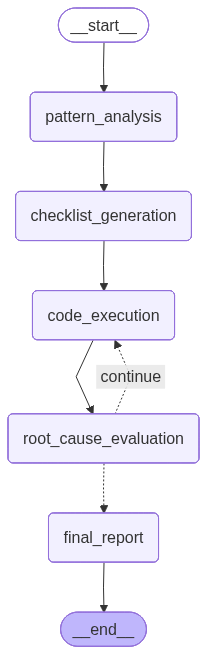

In [8]:
from IPython.display import Image, display

# After creating your graph (app = workflow.compile())
display(Image(app.get_graph().draw_mermaid_png()))


In [9]:
def test_data_access():
    """Test if your data sources are accessible"""
    print("🔍 Testing Data Access...")
    
    # Test CSV files
    print("\n--- Testing CSV Files ---")
    try:
        import os
        csv_files = os.listdir("metrics/")
        print(f"Found CSV files: {csv_files}")
        
        for file in csv_files[:2]:  # Test first 2 files
            if file.endswith('.csv'):
                df = pd.read_csv(f"metrics/{file}")
                print(f"✅ {file}: {df.shape} - Columns: {list(df.columns)[:5]}")
    except Exception as e:
        print(f"❌ CSV Error: {e}")
    
    # Test SQLite database
    print("\n--- Testing SQLite Database ---")
    try:
        conn = sqlite3.connect('synthetic_data/synthetic_data.db')
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()
        print(f"✅ Database tables: {[t[0] for t in tables]}")
        
        # Test first table
        if tables:
            table_name = tables[0][0]
            cursor.execute(f"SELECT COUNT(*) FROM {table_name};")
            count = cursor.fetchone()[0]
            print(f"✅ {table_name} has {count} rows")
            
        conn.close()
    except Exception as e:
        print(f"❌ Database Error: {e}")

# Run the test
test_data_access()


🔍 Testing Data Access...

--- Testing CSV Files ---
Found CSV files: ['monthly_metrics.csv', 'weekly_product_share.csv', 'nth_week_monthly_change.csv', 'weekly_metrics.csv']
✅ monthly_metrics.csv: (48, 3) - Columns: ['month_start', 'monthly_sales', 'pct_change_month']
✅ weekly_product_share.csv: (47995, 7) - Columns: ['order_date', 'category', 'sub_category', 'product_name', 'sales']

--- Testing SQLite Database ---
✅ Database tables: ['inventory', 'store_operations', 'marketing', 'competitor', 'logistics', 'customer_behavior', 'external_factors', 'pricing']
✅ inventory has 1276208 rows


In [10]:
# Updated initialization with error handling
def run_root_cause_analysis_fixed(query: str, max_iterations: int = 10):
    """Run root cause analysis with better error handling"""
    
    print("🔧 Pre-flight checks...")
    
    # Install required packages if needed
    try:
        import matplotlib
        print("✅ Matplotlib available")
    except ImportError:
        print("📦 Installing matplotlib...")
        import subprocess
        subprocess.check_call(['pip', 'install', 'matplotlib', 'seaborn'])
    
    # Test data access
    test_data_access()
    
    # Initialize state with fewer iterations
    initial_state = {
        "messages": [],
        "user_query": query,
        "current_pattern": None,
        "checklist_items": [],
        "executed_queries": [],
        "findings": [],
        "root_cause_found": False,
        "iteration_count": 0,
        "max_iterations": max_iterations,  # Reduced to 3
        "available_metrics": [],
        "available_tables": []
    }
    
    print(f"\n🚀 Starting Root Cause Analysis: {query}")
    print("=" * 60)
    
    try:
        final_state = app.invoke(initial_state)
        
        print("\n" + "=" * 60)
        print("📋 ANALYSIS COMPLETE")
        print("=" * 60)
        
        # Show results
        for message in final_state["messages"]:
            if isinstance(message, AIMessage):
                print(f"\n{message.content}")
        
        return final_state
        
    except Exception as e:
        print(f"❌ Analysis error: {str(e)}")
        return None

# Test with your query
result = run_root_cause_analysis_fixed(
    "Profit for Home Office segment dropped between 2012 january and 2012 march",
    max_iterations=10
)


🔧 Pre-flight checks...
✅ Matplotlib available
🔍 Testing Data Access...

--- Testing CSV Files ---
Found CSV files: ['monthly_metrics.csv', 'weekly_product_share.csv', 'nth_week_monthly_change.csv', 'weekly_metrics.csv']
✅ monthly_metrics.csv: (48, 3) - Columns: ['month_start', 'monthly_sales', 'pct_change_month']
✅ weekly_product_share.csv: (47995, 7) - Columns: ['order_date', 'category', 'sub_category', 'product_name', 'sales']

--- Testing SQLite Database ---
✅ Database tables: ['inventory', 'store_operations', 'marketing', 'competitor', 'logistics', 'customer_behavior', 'external_factors', 'pricing']
✅ inventory has 1276208 rows

🚀 Starting Root Cause Analysis: Profit for Home Office segment dropped between 2012 january and 2012 march
🔍 Starting pattern analysis...
📋 Generating investigation checklist...
⚡ Executing analysis code...
SELECT stockout_flag FROM inventory WHERE product_id LIKE 'OFF-HO%' AND week BETWEEN '2012-01-01' AND '2012-03-31'
🎯 Evaluating findings for root cause.